# Deconvolution 0.2

## Introduction

Here the deconvolution of ST LNs samples using the snRNA-seq data is performed.

In [1]:
setwd("/scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant")

## Libraries

In [2]:
library(here)
library(glue)
library(tidyverse)
library(BiocParallel)
library(HDF5Array)
library(SingleCellExperiment)
library(scater)
library(scran)
library(SPOTlight)

here() starts at /scratch_isilon/groups/singlecell/shared/projects/covid-pascual-reguant

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SparseArray

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: BiocGenerics

Loading required package: gen

## Load data

In [3]:
ref <- loadHDF5SummarizedExperiment(dir = "~/SP-COVID/visium/1-deconvolution/data/spatial_tonsil_atlas/tonsil_atlas_normalized")
ref

spe <- loadHDF5SummarizedExperiment(dir = "~/SP-COVID/visium/0-processing/out/3-annot_ln_spe")
spe

class: SingleCellExperiment 
dim: 970 1805925 
metadata(3): ths ths ths
assays(2): counts logcounts
rownames(970): AATK ABL1 ... ZBTB16 ZFP36
rowData names(6): epi tcs ... mye all
colnames(1805925): S1.c_1_94_1 S1.c_1_94_3 ... S1.c_1_93_6832
  S1.c_1_93_6833
colData names(75): fov Area ... section_id sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(3): Negative SystemControl COMMOT

Loading required namespace: SpatialExperiment



class: SpatialExperiment 
dim: 30426 11641 
metadata(0):
assays(2): counts logcounts
rownames(30426): ENSG00000238009 ENSG00000241860 ... SCoV2_ORF10
  SCoV2_UTR3
rowData names(5): symbol subsets_mito subsets_ribo subsets_SCoV2
  gene_name
colnames(11641): AAACAAGTATCTCCCA-1 AAACAATCTACTAGCA-1 ...
  TTGTTTCACATCCAGG-1 TTGTTTGTGTAAATTC-1
colData names(39): in_tissue array_row ... lisi_study_id annotation
reducedDimNames(3): PCA UMAP HARMONY
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

In [4]:
colnames(spe) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")
rowData(spe)$ensembl <- rownames(spe)
rownames(spe) <- rowData(spe)$gene_name

In [5]:
common_genes <- intersect(rownames(ref), rowData(spe)$gene_name)
length(common_genes)  

ref <- ref[common_genes, ]
spe <- spe[common_genes, ]

[1] 970

## Preprocessing

If the dataset is very large we want to downsample it to train the model, both in of number of cells and number of genes. To do this, we want to keep a representative amount of cells per cluster and the most biologically relevant genes.

In the paper we show how downsampling the **number of cells per cell identity to ~100** doesn’t affect the performance of the model. Including >100 cells per cell identity provides marginal improvement while greatly increasing computational time and resources. Furthermore, restricting the gene set to the **marker genes for each cell type along with up to 300 highly variable genes** further optimizes performance and computational resources. You can find a more detailed explanation in the original paper.

### Feature selection

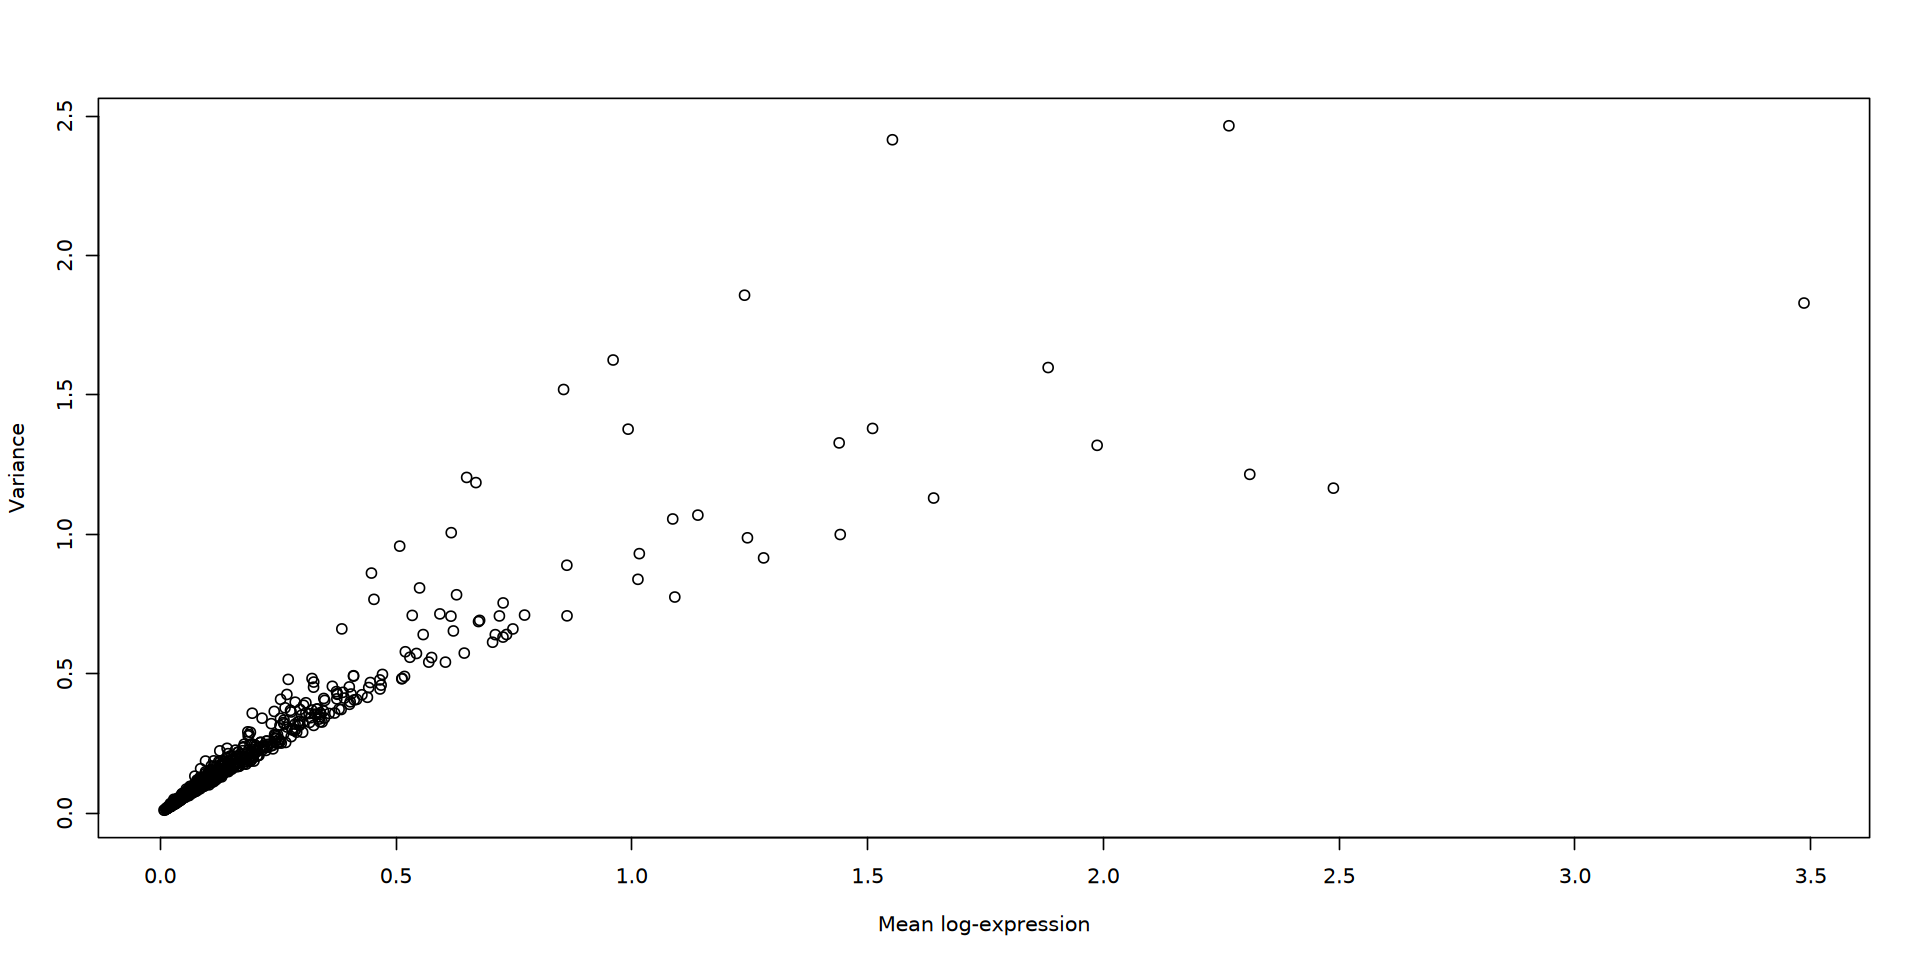

In [6]:
options(repr.plot.width = 16, repr.plot.height = 8, warn = -1)

genes <- !grepl(pattern = "^RP[LS]|^MT-|^MTRNR", x = rownames(ref))

dec <- modelGeneVar(ref, subset.row = genes, block = ref$section_id)
plot(dec$mean, dec$total, xlab = "Mean log-expression", ylab = "Variance")

In [7]:
hvg <- getTopHVGs(dec, n = length(common_genes)) 

In [8]:
colLabels(ref) <- colData(ref)$lv1
mgs <- scoreMarkers(ref, subset.row = genes)

We will keep marker genes with AUC > 0.8.

In [9]:
options(max.print = 99999)
mgs_fil <- lapply(names(mgs), function(i) {
    x <- mgs[[i]]
    threshold <- 0.8 
    x <- x[x$mean.AUC > threshold, ]
    if (nrow(x) == 0) return(NULL)
    x <- x[order(x$mean.AUC, decreasing = TRUE), ]
    x$gene <- rownames(x)
    x$cluster <- i
    data.frame(x)
})

mgs_df <- do.call(rbind, mgs_fil)
print(mgs_df[, c("gene", "mean.AUC", "cluster")])

         gene  mean.AUC cluster
HMGN2   HMGN2 0.9118351      Bd
MS4A1   MS4A1 0.8882142      Bn
IGHM     IGHM 0.8674848      Bn
IGHD     IGHD 0.8202715      Bn
LYZ       LYZ 0.8504991     DCc
PLAC8   PLAC8 0.9015016     DCp
GZMB     GZMB 0.8489862     DCp
CLU       CLU 0.9704245     FDC
CXCL13 CXCL13 0.8006264     FDC
APOE     APOE 0.9076291   macro
MMP9     MMP9 0.8648868   macro
PSAP     PSAP 0.8457683   macro
CTSD     CTSD 0.8226676   macro
LYZ1      LYZ 0.8128893   macro
CD68     CD68 0.8008911   macro
CPA3     CPA3 0.8048340    mast
LYZ2      LYZ 0.8681760    mono
IGHG1   IGHG1 0.9245106      PC
IGHG2   IGHG2 0.8973242      PC
IGKC     IGKC 0.8926620      PC


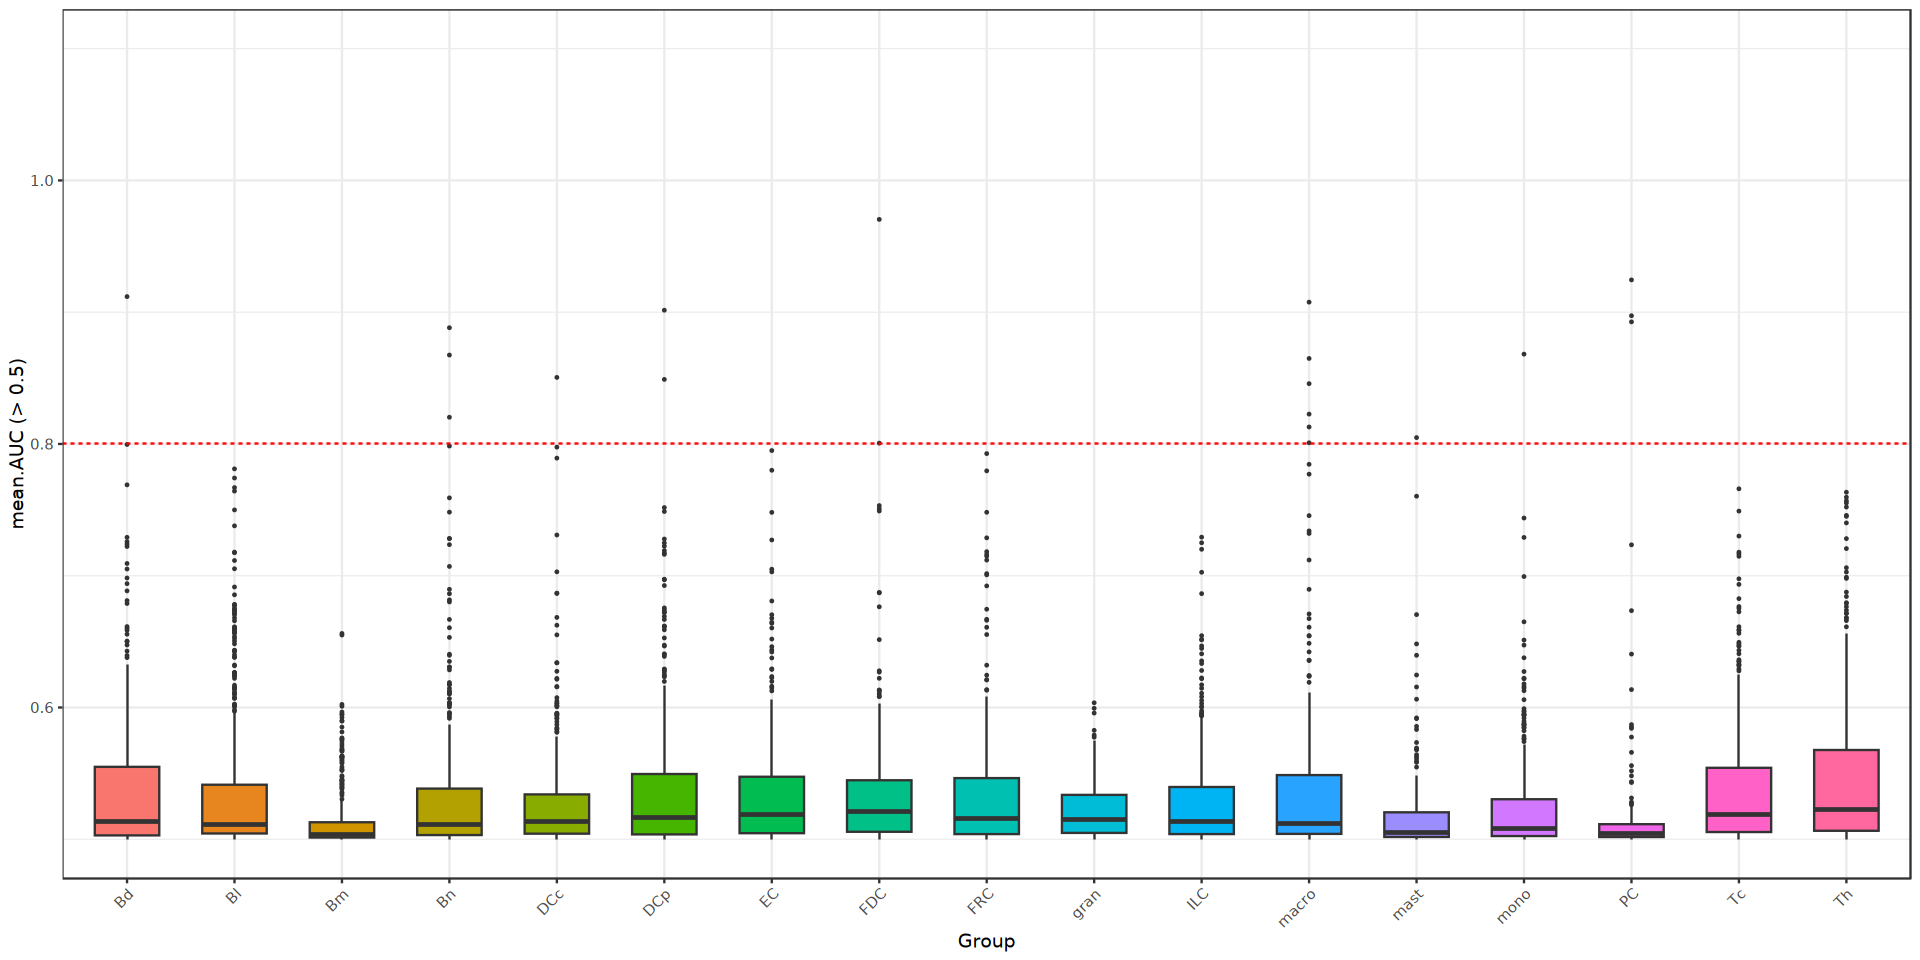

In [10]:
lapply(names(mgs), function(grp) {
    data.frame(mean.AUC = mgs[[grp]]$mean.AUC,
               group = grp)
}) %>% 
do.call(rbind, .) %>%
filter(mean.AUC > 0.5) %>%
 
    ggplot(aes(x = group, y = mean.AUC, fill = group)) +
    geom_boxplot(width = 0.6, outlier.size = 0.3) +
    geom_hline(yintercept = 0.8, linetype = "dashed", color = "red") +
    scale_x_discrete(limits = names(mgs)) +
    scale_y_continuous(limits = c(0.5, 1.1)) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "none") +
    labs(x = "Group", y = "mean.AUC (> 0.5)")

In [11]:
known_markers <- list(
  PC   = c("JCHAIN", "MZB1", "XBP1", "TNFRSF17", "IGKC", "IGHG1", "IGHG2"),
  Bn   = c("SELL", "TCL1A", "IGHM", "IGHD", "CD37", "MS4A1"), 
  Bm   = c("CD27", "CD80", "CD44", "TNFRSF13B", "CD79A"),
  Bl   = c("CXCR5", "CD83", "CD86", "CD40", "BCL2", "CCND1", "CD74"),  
  Bd   = c("CXCR4", "MKI67", "TOP2A", "BIRC5", "UBE2C", "STMN1", "TYMS", "HMGB2", "HMGN2"), 
  Th   = c("CD3D", "CD3E", "CD4", "TCF7", "MAF", "ICOS"),
  Tc   = c("CD3D", "CD3E", "CD8A", "CD8B", "TBX21", "NKG7", "PRF1"),
  ILC  = c("AHR", "RORA", "ZBTB16", "IL7R"),
  EC   = c("VWF", "CDH5", "PECAM1", "LYVE1", "SPARCL1"),  
  FDC  = c("CXCL13", "VCAM1", "CCL19", "TNFRSF11B", "TNFSF13B"),
  FRC  = c("PDGFRB", "CCL21", "ACTA2", "CALD1", "TAGLN"),
  macro = c("C1QA", "C1QB", "CD163", "MRC1", "APOE", "PSAP"),
  mono  = c("CD14", "VCAN", "CCR2", "CLEC12A", "S100A9", "LYZ"),
  mast = c("CPA3", "HPGDS", "PTGDS"),  
  gran = c("ELANE", "MPO", "AZU1", "CAMP", "LCN2", "CXCR1"),
  DCc  = c("CD1C", "CD83", "CCR7", "CD209"),  
  DCp  = c("ANXA1", "STAT1", "TNF", "IL1B", "TYROBP")
)


man_mgs <- imap_dfr(known_markers, function(gene_vec, cl){
  x <- mgs[[cl]]
  if (is.null(x)) return(NULL)

  g_keep <- intersect(gene_vec, rownames(x))
  if (length(g_keep) == 0) return(NULL)

  x_sub <- x[g_keep, , drop = FALSE]
  x_sub$gene <- rownames(x_sub)
  x_sub$cluster <- cl
  as.data.frame(x_sub)
})

mgs_df_all <- bind_rows(mgs_df, man_mgs) %>%
  arrange(cluster, desc(mean.AUC)) %>%
  distinct(cluster, gene, .keep_all = TRUE)

### Cell downsampling

In [12]:
score_cells_by_markers <- function(sce, mgs_df, annotation_col = "annotation") {
  expr <- logcounts(sce)
  clusters <- unique(sce[[annotation_col]])
  scores <- rep(0, ncol(sce))
  names(scores) <- colnames(sce)
  
  for (cl in clusters) {
    markers <- mgs_df %>%
      filter(cluster == cl) %>%
      pull(gene)
    markers <- intersect(markers, rownames(sce))
    
    if (length(markers) == 0) next
    cell_idx <- which(sce[[annotation_col]] == cl)
    weights <- mgs_df %>%
      filter(cluster == cl, gene %in% markers) %>%
      arrange(match(gene, markers)) %>%
      pull(mean.AUC)
    
    marker_expr <- expr[markers, cell_idx, drop = FALSE]
    scores[cell_idx] <- as.numeric(weights %*% marker_expr) / sum(weights)
  }
  
  return(scores)
}

cell_scores <- score_cells_by_markers(ref, mgs_df_all, annotation_col = "lv1")
ref$marker_score <- cell_scores

n_cells <- 100
idx <- split(seq(ncol(ref)), ref$lv1)

cs_keep <- lapply(idx, function(i) {
  n <- min(length(i), n_cells)
  i[order(cell_scores[i], decreasing = TRUE)[1:n]]
})

ref_down <- ref[, unlist(cs_keep)]

bind_cols(
  as.data.frame(table(ref$lv1)),
  as.data.frame(table(ref_down$lv1)) %>% select(Freq)
) %>%
  setNames(c("cluster", "before", "after")) %>%
  knitr::kable()

New names:
• `Freq` -> `Freq...2`
• `Freq` -> `Freq...3`




|cluster | before| after|
|:-------|------:|-----:|
|Bd      |  51436|   100|
|Bl      | 194003|   100|
|Bm      | 465464|   100|
|Bn      | 172792|   100|
|DCc     |  47325|   100|
|DCp     |  10371|   100|
|EC      |  70477|   100|
|FDC     |  41628|   100|
|FRC     | 129902|   100|
|gran    |  44677|   100|
|ILC     |  49272|   100|
|macro   |  93573|   100|
|mast    |   3857|   100|
|mono    |   5710|   100|
|PC      | 192493|   100|
|Tc      |  86310|   100|
|Th      | 146635|   100|

## Deconvolution

In [13]:
res <- SPOTlight(x = ref_down, y = spe,
                 groups = as.character(ref_down$lv1),
                 mgs = mgs_df_all, hvg = hvg,
                 weight_id = "mean.AUC",
                 group_id = "cluster",
                 gene_id = "gene")

Scaling count matrix

Seeding NMF model...

Training NMF model...




iter |      tol 
---------------
   1 | 2.81e-01
   2 | 1.16e-02
   3 | 2.20e-03
   4 | 9.12e-04
   5 | 5.94e-04
   6 | 5.20e-04
   7 | 5.19e-04
   8 | 5.54e-04
   9 | 6.43e-04
  10 | 7.89e-04
  11 | 9.81e-04
  12 | 1.09e-03
  13 | 8.95e-04
  14 | 4.96e-04
  15 | 2.02e-04
  16 | 7.29e-05
  17 | 2.67e-05
  18 | 1.03e-05
  19 | 4.42e-06


Time for training: 0.01min

Removing genes in mixture matrix that are all 0s

Keep intersection of genes between W and mixture matrix

Deconvoluting mixture data...



## Save data

In [14]:
out_dir <- "~/SP-COVID/visium/1-deconvolution/out"

"{out_dir}/deconvolution_results_ln.rds" %>%
    glue::glue() %>%
  saveRDS(object = res, file = .)

saveHDF5SummarizedExperiment(
    x = ref_down, replace = TRUE,
    dir = glue::glue("{out_dir}/ref_downsampled_ln")
)

# Session information

In [15]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] SPOTlight_1.14.0            scran_1.38.0               
 [3] scater_1.38.0               scuttle_1.20.0             
 [5] SingleCellExperiment_1.32.0 SummarizedExperiment_1.40.0
 [7] Biobase_2